# BrushCue Example: Camera Moving Distortion

<a href="https://colab.research.google.com/github/ditotechnologies/brushcue/blob/main/examples/camera_moving_distortion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

You can use this tool online at https://www.brushcue.com/tools/camera-moving-distortion

In [ ]:
!pip install brushcue

[wgpu] using backend Metal — adapter 'Apple M5' (IntegratedGpu), driver ''


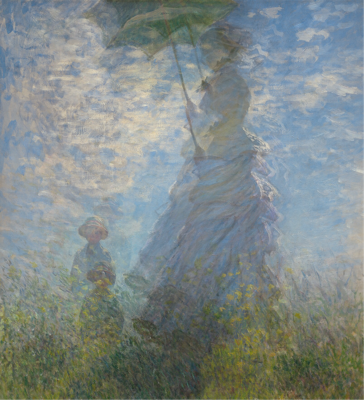

In [1]:
import io
from PIL import Image

import brushcue as bc

input_image = bc.Composition.monet_women_with_parasol()
intensity = 0.3
alpha_transform = input_image.linear_transform(
    1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, intensity
)
first_offset = bc.Vector2f.from_components(
    (input_image.bounds().width() * 0.039), (input_image.bounds().height() * (-0.04))
)
second_offset = bc.Vector2f.from_components(
    (input_image.bounds().width() * 0.021), (input_image.bounds().height() * 0.092)
)
max_x = first_offset.x().abs().max(second_offset.x().abs())
max_y = first_offset.y().abs().max(second_offset.y().abs())
graph = alpha_transform.blend_alpha(
    alpha_transform.blend_alpha(
        input_image, bc.Transform2.identity().translation(first_offset)
    ),
    bc.Transform2.identity().translation(second_offset),
).crop(
    bc.Bounds2f.from_x_y_width_height(
        (input_image.bounds().min_x() + max_x),
        (input_image.bounds().min_y() + max_y),
        (input_image.bounds().width() - (max_x * 2.0)),
        (input_image.bounds().height() - (max_y * 2.0)),
    )
)

ctx = bc.Context()
composition = graph.execute(ctx)
data_bytes = composition.to_image_bytes(ctx)
img = Image.open(io.BytesIO(data_bytes))
img.thumbnail((400, 400))  # Remove this line for full resolution
img
